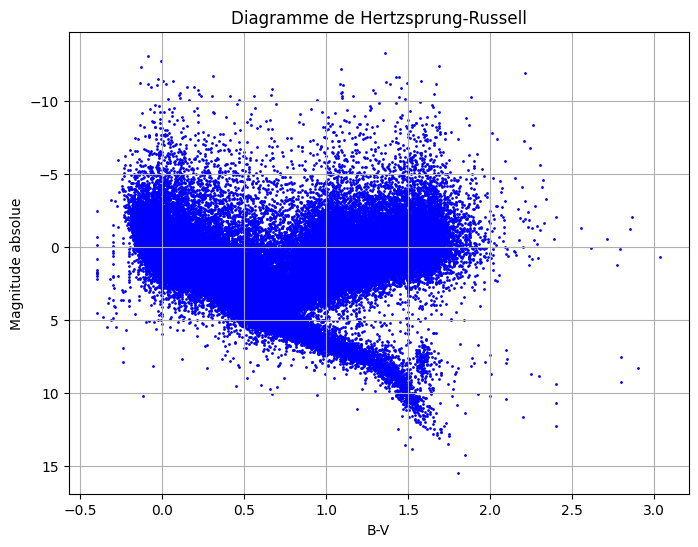

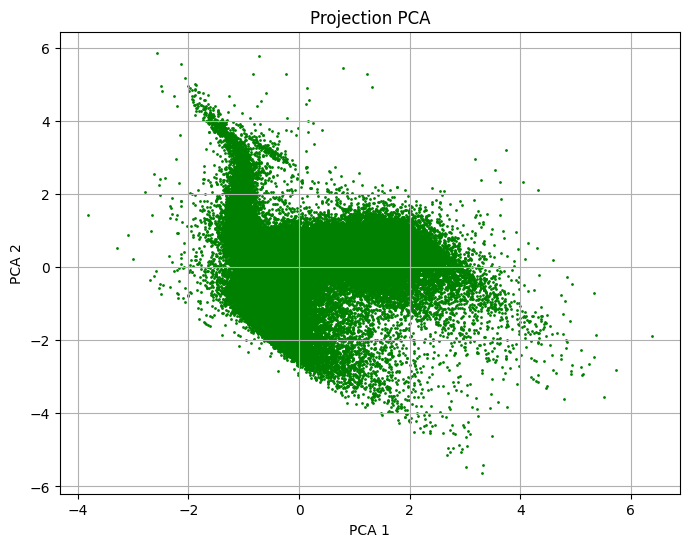

/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


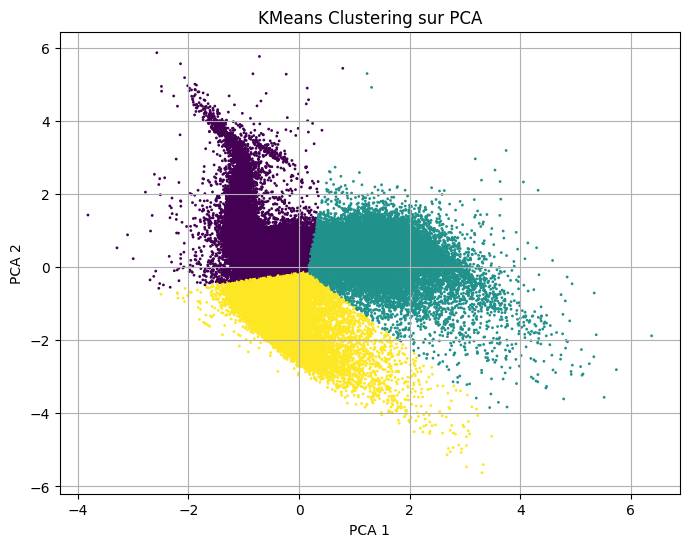

Silhouette score du clustering: 0.48
Rapport de classification :
              precision    recall  f1-score   support

           A       0.72      0.73      0.73      3668
           B       0.67      0.61      0.63      1894
           F       0.77      0.81      0.79      5020
           G       0.66      0.62      0.64      4432
           K       0.76      0.81      0.79      6148
           M       0.55      0.42      0.48       873
           O       0.14      0.03      0.05        37

    accuracy                           0.72     22072
   macro avg       0.61      0.57      0.58     22072
weighted avg       0.72      0.72      0.72     22072

Matrice de confusion :
[[2675  507  443   27   11    1    4]
 [ 635 1146   80   21   10    0    2]
 [ 345   35 4054  535   48    3    0]
 [  19   10  678 2738  983    4    0]
 [   4    3   30  840 4974  297    0]
 [   0    1    3    8  491  370    0]
 [  12   17    6    1    0    0    1]]


In [7]:
# Projet Machine Learning - Diagramme de Hertzsprung-Russell (HR)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# 1. Chargement des données
df = pd.read_csv("data.csv")

# 2. Nettoyage et préparation
df_hr = df[['B-V', 'Vmag', 'Plx', 'SpType']].copy()
df_hr.dropna(inplace=True)
df_hr = df_hr[df_hr['Plx'] > 0]
df_hr['AbsMag'] = df_hr['Vmag'] - 5 * (np.log10(1000 / df_hr['Plx']) - 1)

# Nettoyage des types spectraux
df_hr['SpClass'] = df_hr['SpType'].str[0]
df_hr = df_hr[df_hr['SpClass'].isin(['O', 'B', 'A', 'F', 'G', 'K', 'M'])]

# 3. Visualisation du diagramme HR
plt.figure(figsize=(8, 6))
plt.scatter(df_hr['B-V'], df_hr['AbsMag'], s=1, c='blue')
plt.gca().invert_yaxis()
plt.xlabel('B-V')
plt.ylabel('Magnitude absolue')
plt.title('Diagramme de Hertzsprung-Russell')
plt.grid(True)
plt.show()

# 4. PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_hr[['B-V', 'AbsMag']])
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=1, c='green')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Projection PCA')
plt.grid(True)
plt.show()

# 5. Clustering (KMeans)
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_pca)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, s=1, cmap='viridis')
plt.title('KMeans Clustering sur PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.grid(True)
plt.show()

score = silhouette_score(X_pca, labels)
print(f"Silhouette score du clustering: {score:.2f}")

# 6. Classification supervisée : prédire SpClass
label_enc = LabelEncoder()
df_hr['SpEncoded'] = label_enc.fit_transform(df_hr['SpClass'])
X = df_hr[['B-V', 'AbsMag']]
y = df_hr['SpEncoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Rapport de classification :")
print(classification_report(y_test, y_pred, target_names=label_enc.classes_))
print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))
